A simplified version of fast_phoenix_many to try fittting simpler handmade "spectra"

In [19]:
import numpy as np
from astropy.modeling import models
from astropy import units as u

from astropy.visualization import quantity_support
quantity_support()

from matplotlib import pyplot as plt

In [6]:
import jax
import jax.numpy as jnp
import equinox as eqx
import optax
rkey = jax.random.PRNGKey(42)
jax.devices()

[CpuDevice(id=0)]

In [13]:
wl = np.linspace(4000, 8000, 2048)*u.angstrom

In [16]:
bb = models.BlackBody(temperature=5800*u.K, scale=1*u.erg/(u.cm**2 * u.s * u.angstrom * u.sr))

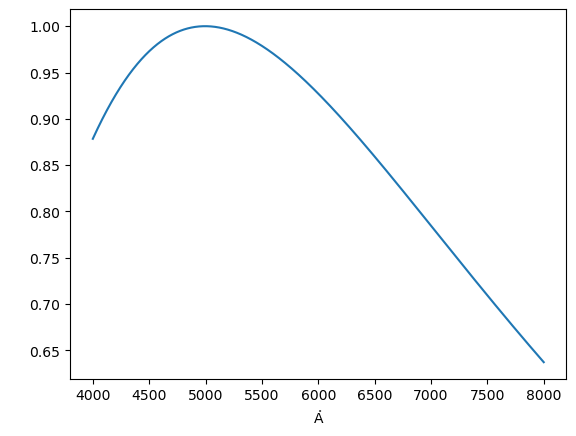

In [22]:
bbeval = bb(wl)
bbevaln = bbeval / np.max(bbeval)
plt.plot(wl, bbevaln);

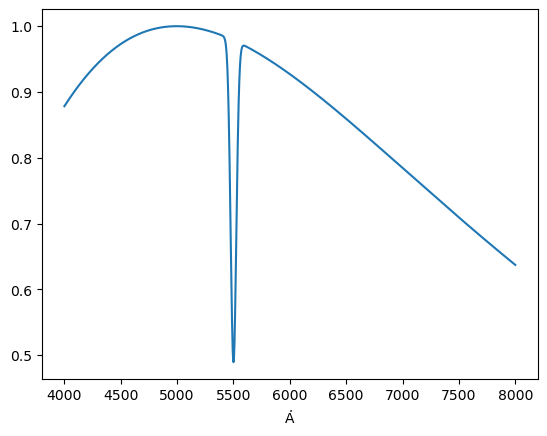

In [27]:
jwl = jnp.array(wl.value)
base_data = jnp.array(bbevaln)
def generate_data(center, width=25, amplitude=0.5):
    line = amplitude * jnp.exp(-0.5 * ((jwl- center) / width)**2)
    return base_data*(1 - line)

plt.plot(wl, generate_data(5500))

On pause to investigate transformer-based fast options